In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib 
import os

C:\Users\Luis\AppData\Roaming\Python\Python38\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
os.chdir('C:/Users/Luis/Box/R15 Sensor Preprocessing and Analysis/JPCS Special Issue') #set directory for desktop
#os.chdir('/Users/sandoval/Library/CloudStorage/Box-Box/R15 Sensor Preprocessing and Analysis/JPCS Special Issue') #this is for when i use my mac instead of my desktop
raw = pd.read_csv('Full_Summary_Features_clean_2-24-2024.csv') #filtered summary data from madison

In [3]:
#i want to see all the columns so i can specifically pick the features i actually want
    #we are going to make a dataset containing just restrict alongside predictors aka physio
    #then we are going to make another dataset containing just urge to restrict alongside physio
    #we don't want to include any other EMA in our train/test data for each analysis

for col in raw.columns: 
    print(col) 

Unnamed..0
Time
HR_Mean
HR_Minimum
HR_Maximum
HR_Stdev
HR_RMS
HR_MAD
HR_MAV
HR_Median
HR_P25
HR_P75
EDA_Mean
EDA_Minimum
EDA_Maximum
EDA_Stdev
EDA_RMS
EDA_MAD
EDA_MAV
EDA_Median
EDA_P25
EDA_P75
TEMP_Mean
TEMP_Minimum
TEMP_Maximum
TEMP_Stdev
TEMP_RMS
TEMP_MAD
TEMP_MAV
TEMP_Median
TEMP_P25
TEMP_P75
meanCenteredEDA_Mean
meanCenteredEDA_Minimum
meanCenteredEDA_Maximum
meanCenteredEDA_Stdev
meanCenteredEDA_RMS
meanCenteredEDA_MAD
meanCenteredEDA_MAV
meanCenteredEDA_Median
meanCenteredEDA_P25
meanCenteredEDA_P75
meanCenteredHR_Mean
meanCenteredHR_Minimum
meanCenteredHR_Maximum
meanCenteredHR_Stdev
meanCenteredHR_RMS
meanCenteredHR_MAD
meanCenteredHR_MAV
meanCenteredHR_Median
meanCenteredHR_P25
meanCenteredHR_P75
meanCenteredTEMP_Mean
meanCenteredTEMP_Minimum
meanCenteredTEMP_Maximum
meanCenteredTEMP_Stdev
meanCenteredTEMP_RMS
meanCenteredTEMP_MAD
meanCenteredTEMP_MAV
meanCenteredTEMP_Median
meanCenteredTEMP_P25
meanCenteredTEMP_P75
ethica_time
lag
tdif
cumsumT
ethica_time_utc
dayvar
beepvar


In [4]:
#descriptives for paper

raw['restrict'].mean()
raw['restrict'].min()
raw['restrict'].max()
raw['restrict'].std()

34.06041654648963

In [5]:
raw['urge_restrict'].mean()
raw['urge_restrict'].min()
raw['urge_restrict'].max()
raw['urge_restrict'].std()

31.124504242823576

In [6]:
#row_nan_count = .isna().sum(axis=1)

raw["urge_restrict"].isna().sum() #71 urge_restrict points missing 
raw["restrict"].isna().sum() #54 restrict items missing
len(raw["urge_restrict"])
raw.head()

,Unnamed..0,Time,HR_Mean,HR_Minimum,HR_Maximum,HR_Stdev,HR_RMS,HR_MAD,HR_MAV,HR_Median,...,socialanx_medCentered,sens_body_meanCentered,sens_body_medCentered,ridthoughts_meanCentered,ridthoughts_medCentered,memories_meanCentered,memories_medCentered,chewspit_meanCentered,chewspit_medCentered,PR
0,117,58:00.0,93.129563,66.83,120.20,14.947826,94.321047,13.171499,120.20,94.55,...,21.0,0.279661,-1.0,13.211864,3.0,10.110169,-0.5,0.0,0.0,PR003
1,116,28:00.0,67.698626,56.77,85.90,6.844791,68.043630,5.718079,85.90,67.03,...,22.0,3.279661,2.0,7.211864,-3.0,-58.889831,-69.5,0.0,0.0,PR003
2,115,56:00.0,70.553065,55.93,93.38,9.837114,71.235269,7.708571,93.38,68.85,...,0.0,-1.720339,-3.0,12.211864,2.0,-58.889831,-69.5,0.0,0.0,PR003
3,114,56:00.0,90.937768,57.98,149.50,25.878040,94.546664,23.029055,149.50,84.10,...,0.0,-2.720339,-4.0,3.211864,-7.0,9.110169,-1.5,0.0,0.0,PR003
4,113,25:00.0,74.612836,57.92,93.05,10.477028,75.344527,8.849632,93.05,75.70,...,0.0,1.279661,0.0,17.211864,7.0,9.110169,-1.5,0.0,0.0,PR003


In [7]:
#random seed. I picked 6 because I like 6 and i always pick 6. this is so we get the same results every time
np.random.seed(6)

In [8]:
corrs = raw.filter(['meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev',  
                    'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median',
                    'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                    'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD',
                    'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75',
                    'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev',
                    'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median',
                    'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'urge_restrict', 'restrict'])

In [9]:
corrs = corrs.rename(columns={"meanCenteredEDA_Mean" : "EDA_Mean",
                      "meanCenteredEDA_Minimum" : "EDA_Minimum",
                      "meanCenteredEDA_Maximum" : "EDA_Maximum",
                      "meanCenteredEDA_Stdev" : "EDA_Stdev",
                      "meanCenteredEDA_RMS" : "EDA_RMS",
                      "meanCenteredEDA_MAD" : "EDA_MAD",
                      "meanCenteredEDA_MAV" : "EDA_MAV",
                      "meanCenteredEDA_Median" : "EDA_Median",
                      "meanCenteredEDA_P25" : "EDA_P25",
                      "meanCenteredEDA_P75" : "EDA_P75",
                      "meanCenteredHR_Mean" : "HR_Mean",
                      "meanCenteredHR_Minimum" : "HR_Minimum",
                      "meanCenteredHR_Maximum" : "HR_Maximum",
                      "meanCenteredHR_Stdev" : "HR_Stdev",
                      "meanCenteredHR_RMS" : "HR_RMS",
                      "meanCenteredHR_MAD" : "HR_MAD",
                      "meanCenteredHR_MAV" : "HR_MAV",
                      "meanCenteredHR_Median" : "HR_Median",
                      "meanCenteredHR_P25" : "HR_P25",
                      "meanCenteredHR_P75" : "HR_P75",
                      "meanCenteredTEMP_Mean" : "TEMP_Mean",
                      "meanCenteredTEMP_Minimum" : "TEM_Minimum",
                      "meanCenteredTEMP_Maximum" : "TEMP_Maximum",
                      "meanCenteredTEMP_Stdev" : "TEMP_Stdev",
                      "meanCenteredTEMP_RMS" : "TEMP_RMS",
                      "meanCenteredTEMP_MAD" : "TEMP_MAD",
                      "meanCenteredTEMP_MAV" : "TEMP_MAV",
                      "meanCenteredTEMP_Median" : "TEMP_Median",
                      "meanCenteredTEMP_P25" : "TEMP_P25",
                      "meanCenteredTEMP_P75" : "TEMP_P75",
                      "urge_restrict" : "urge_restrict",
                      "restrict" : "restrict"})

In [10]:
Corr_Matrix = round(corrs.corr(),2)
print(Corr_Matrix)

               EDA_Mean  EDA_Minimum  EDA_Maximum  EDA_Stdev  EDA_RMS  \
EDA_Mean           1.00         0.86         0.93       0.69     0.92   
EDA_Minimum        0.86         1.00         0.65       0.28     0.70   
EDA_Maximum        0.93         0.65         1.00       0.89     0.92   
EDA_Stdev          0.69         0.28         0.89       1.00     0.77   
EDA_RMS            0.92         0.70         0.92       0.77     1.00   
EDA_MAD            0.69         0.28         0.88       1.00     0.76   
EDA_MAV            0.88         0.58         0.97       0.90     0.96   
EDA_Median         1.00         0.88         0.90       0.65     0.91   
EDA_P25            0.98         0.93         0.85       0.54     0.87   
EDA_P75            0.99         0.80         0.95       0.76     0.93   
HR_Mean            0.11         0.07         0.12       0.11     0.16   
HR_Minimum         0.11         0.07         0.13       0.11     0.16   
HR_Maximum         0.07         0.05         0.08  

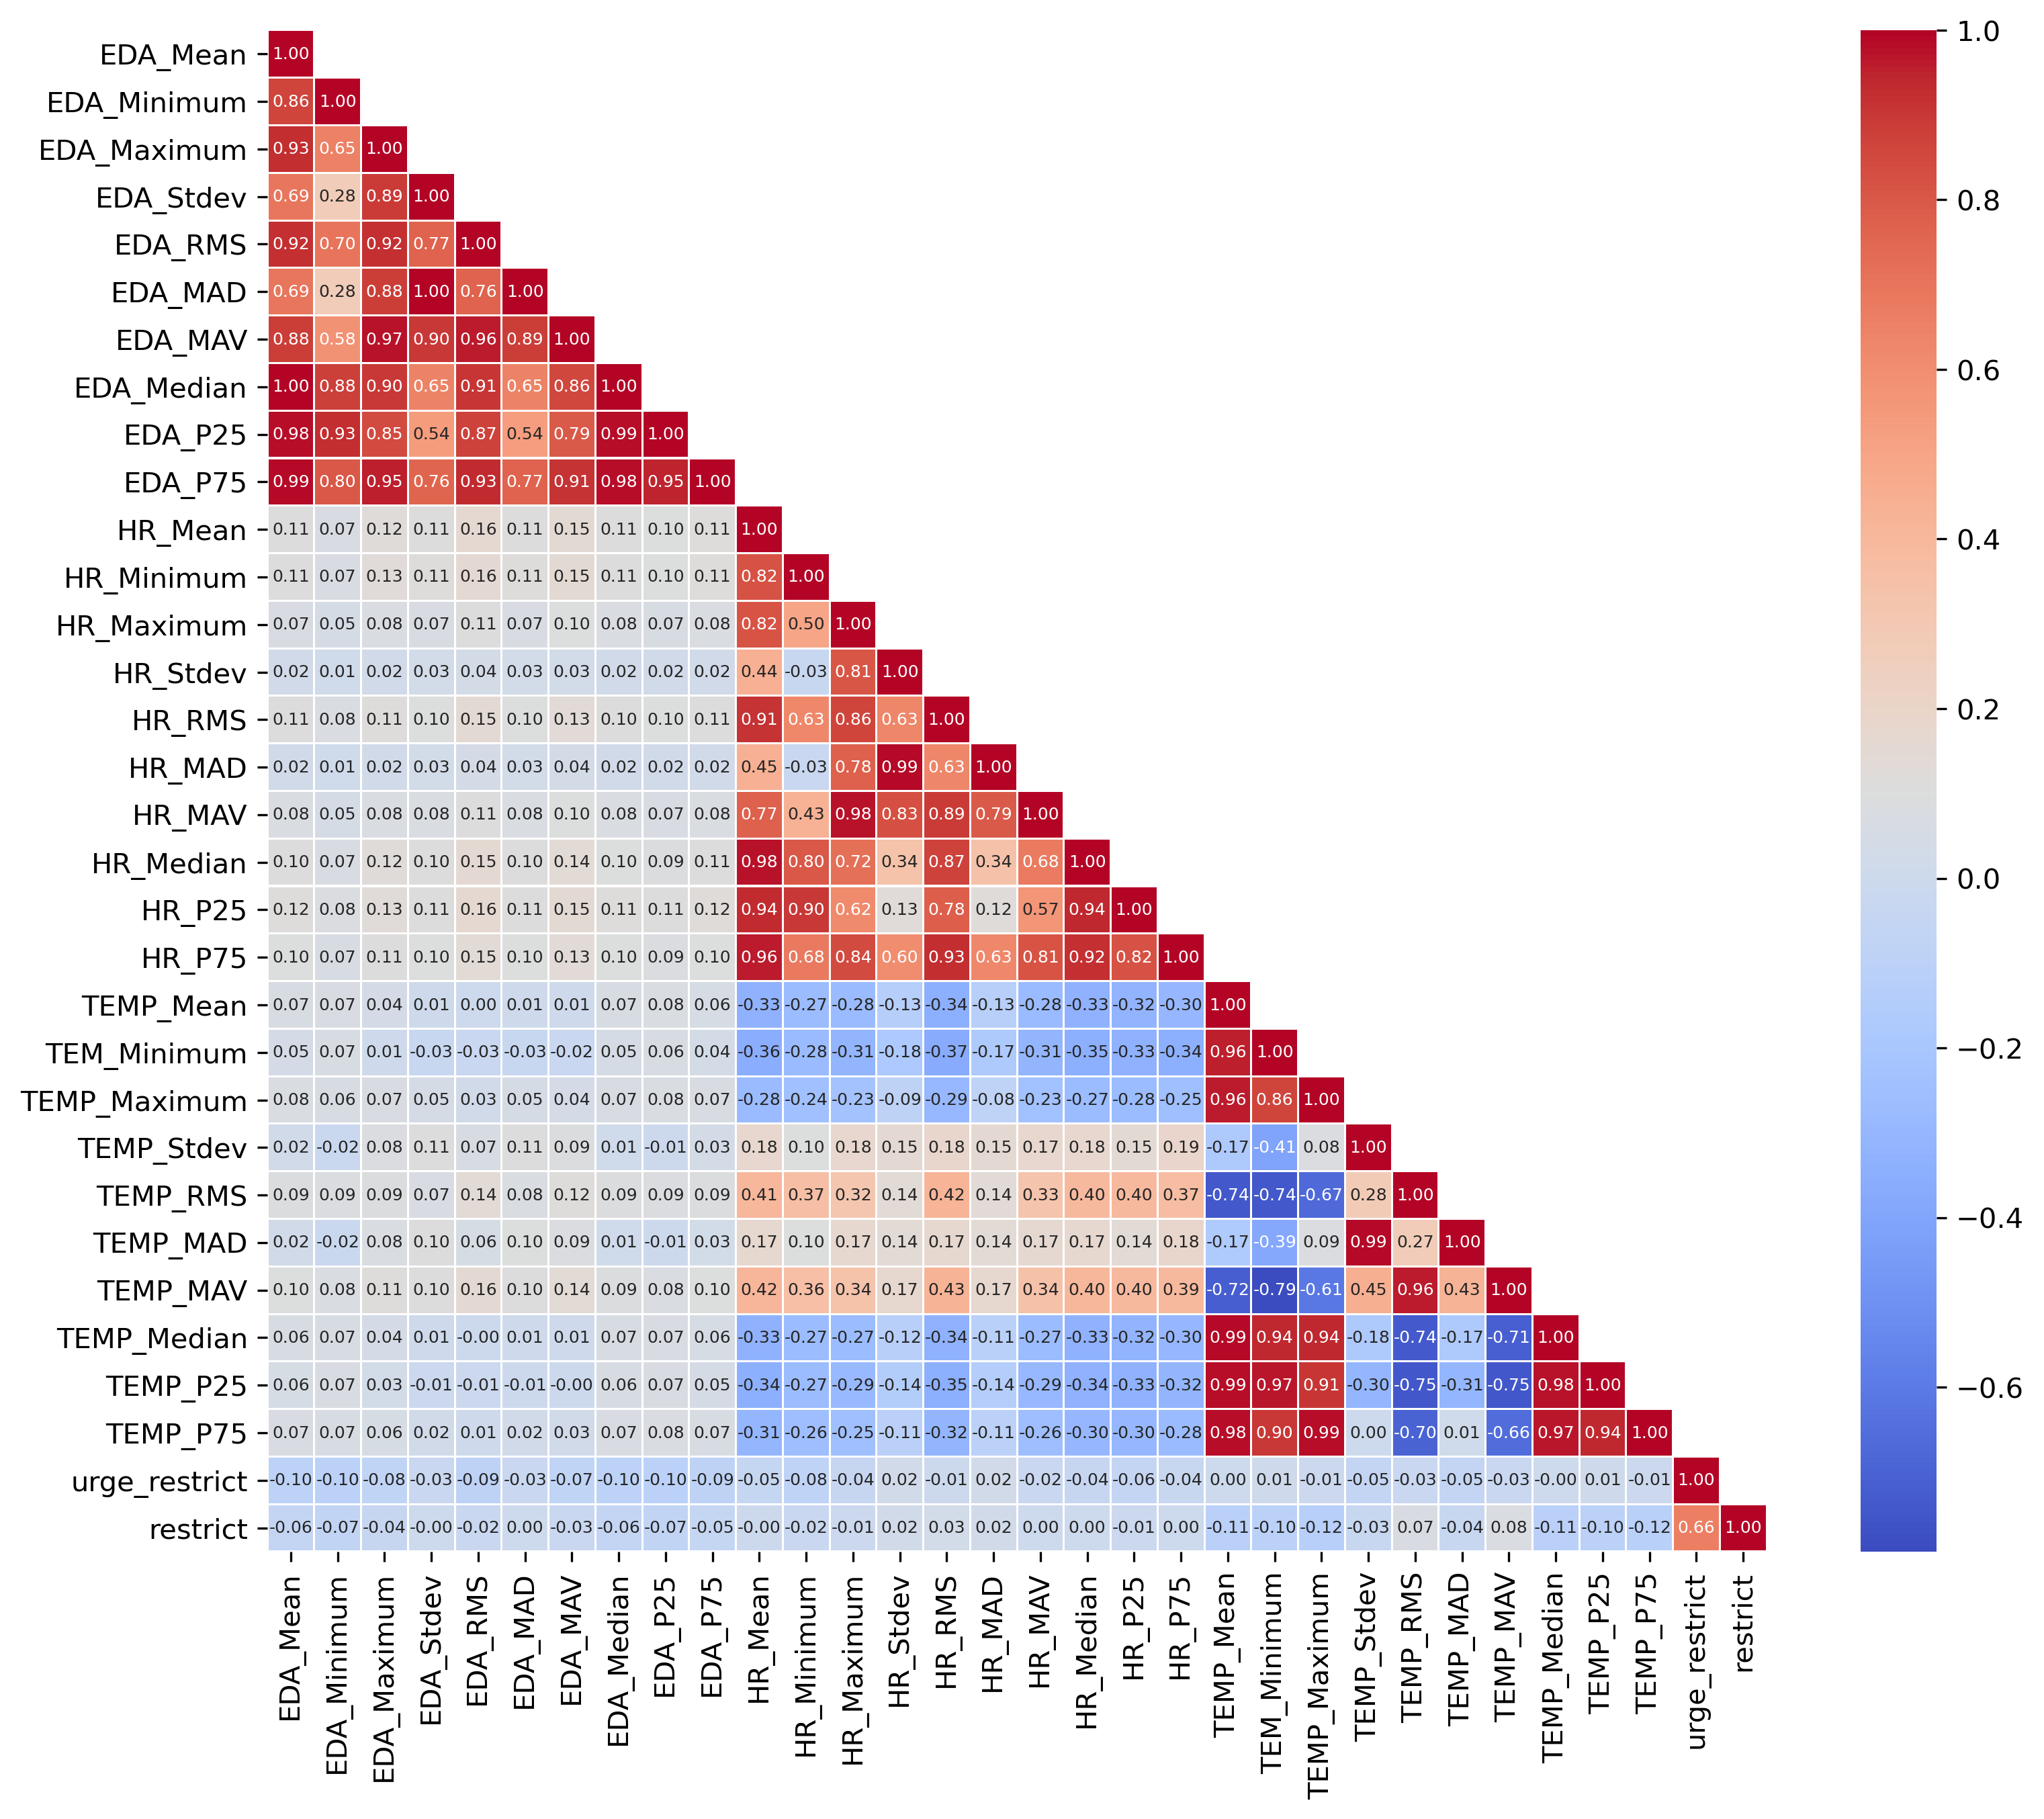

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_full = corrs.corr()

mask = np.zeros_like(correlation_full, dtype=bool)
mask[np.triu_indices_from(mask)] = True
np.fill_diagonal(mask, False)
 
plt.figure(figsize=(12,10), dpi =300)
sns.heatmap(correlation_full,fmt=".2f", linewidth=.5, cmap = 'coolwarm', mask = mask, annot=True,annot_kws={"fontsize": 6})
plt.show()

In [12]:
#creating the dataset for predicting urge_restrict from physio alone
urgeData = raw.filter(['meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'urge_restrict'])

In [13]:
#creating the dataset for predicting restrict from physio alone
restrictData = raw.filter(['meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'restrict'])

In [14]:
urgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(urgeData['urge_restrict'])) #check that NAs exist - if false, we are good

restrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(restrictData['restrict'])) #check that NAs exist - if false, we are good

False

In [15]:
#we want to randomly assort the rows in these dataframes now since they're clustered by participant
restrictDataShuffled = restrictData.sample(frac = 1) #shuffle restriction dataset
urgeDataShuffled = urgeData.sample(frac = 1) #shuffle urge dataset

In [16]:
#now what i want to do is reserve a portion of the data to test after the fact - the remaining data we'll do k-fold grid search cross validation
#we're going to split the data as follows: 
#80% of the data is going to be the train/test data for the model
#the remaining 20% will be held and we will use the trained/tested model to see how closely it predicts the 20% holdover set

from sklearn.model_selection import train_test_split

urgeX = urgeDataShuffled.drop(columns = {'urge_restrict'}) #drop urge_restrict from dataframe for the splitting
urgey = urgeDataShuffled.filter(['urge_restrict']) #make a dataframe containing only urge_restrict variable

restX = restrictDataShuffled.drop(columns = {'restrict'})
resty = restrictDataShuffled.filter(['restrict'])

In [17]:
urgeX_train, urgeX_test, urgey_train, urgey_test = train_test_split(urgeX, urgey, random_state=6,test_size=0.20) 
restX_train, restX_test, resty_train, resty_test = train_test_split(restX, resty, random_state=6,test_size=0.20) 
#we're sticking with 6 for random_state
#the test sets are what we are going to validate our models on later

In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from numpy import arange

#we're going to start exclusively with the urge data for now, we'll circle back to the restrict data later 

urgeMod = ElasticNet(max_iter = 1000) 
urgecv = RepeatedKFold(n_splits=5, n_repeats=1, random_state=6) #i still like 6, we're doing a 10-fold cross-validation repeating 3 times

In [4]:
from numpy import mean
from numpy import std
from numpy import absolute

def cross_validation(model, _X, _y, _cv):
    param_grid = {'alpha'     : [0.1,1,10,0.01],
                'l1_ratio'  :  np.arange(0.40,1.00,0.10),
                'tol'       : [0.0001,0.001] }
    _scoring = ['neg_mean_absolute_error', 'neg_mean_squared_error', 'r2']
    grid_search = GridSearchCV(estimator = model, param_grid = param_grid, cv = _cv, scoring = _scoring, return_train_score = True, refit= 'neg_mean_absolute_error', n_jobs = -1)
    grid_search.fit(X = _X, y = _y,)
    d = dict()
    d['results'] = pd.DataFrame(grid_search.cv_results_)
    alpha = format(grid_search.best_params_).partition("{'alpha': ")[2]
    d['alpha'] = alpha.partition(",")[0]
    l1 = format(grid_search.best_params_).partition("'l1_ratio': ")[2]
    d['l1'] = l1.partition(",")[0]
    tol = format(grid_search.best_params_).partition("'tol': ")[2]
    d['tol'] = tol.partition("}")[0]
    print("Best parameters : {}".format(grid_search.best_params_))
    print("Best cross validation score: {:.2f}".format(grid_search.best_score_))
    print("Best estimator: {}".format(grid_search.best_estimator_))
    print("Best alpha : " + d['alpha'])
    print("Best L1 : " + d['l1'])
    print("Best tol : " + d['tol'])
    return d
           

In [5]:
urgecv_result = cross_validation(urgeMod, urgeX_train, urgey_train, urgecv)
urgecv_r2 = urgecv_result['results']['mean_train_r2'].mean()
print("Train R2 = " + str(urgecv_r2))

NameError: name 'urgeMod' is not defined

In [21]:
urgecv_r2med = urgecv_result['results']['mean_train_r2'].median()
print("Train R2 = " + str(urgecv_r2med))

Train R2 = 0.04495040349108069


In [22]:
### now we build the final model for urge - we are using the optimal hyperparameters divulged through the grid search 
### to fit a final model and then test it on the hold-out test set
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.metrics import mean_absolute_error as mae 
from sklearn.metrics import r2_score

urgeModTuned = ElasticNet(alpha = 1, l1_ratio = .4, tol = .001).fit(urgeX_train,urgey_train)
urgeyPred = urgeModTuned.predict(urgeX_test)
mae(urgey_test,urgeyPred) #MAE = 25.24
r2_score(urgey_test,urgeyPred) #R2 = .0182

0.018230596622308415

In [182]:
#trying restrict now 

restMod = ElasticNet(max_iter = 1000)
restcv = RepeatedKFold(n_splits=5, n_repeats=1, random_state=6)
restcv_result = cross_validation(restMod, restX_train, resty_train, restcv)
restcv_r2 = restcv_result['results']['mean_train_r2'].mean()
print("Train R2 = " + str(restcv_r2))

Best parameters : {'alpha': 0.01, 'l1_ratio': 0.8999999999999999, 'tol': 0.0001}
Best cross validation score: -29.36
Best estimator: ElasticNet(alpha=0.01, l1_ratio=0.8999999999999999)
Best alpha : 0.01
Best L1 : 0.8999999999999999
Best tol : 0.0001
Train R2 = 0.05276069843941667


C:\Users\Luis\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 677983.6592962635, tolerance: 164.090367887324
  model = cd_fast.enet_coordinate_descent(


In [184]:
restcv_r2med = restcv_result['results']['mean_train_r2'].median()
print("Train R2 = " + str(restcv_r2med))

Train R2 = 0.05681341874532231


In [194]:
restModTuned = ElasticNet(alpha = float(restcv_result['alpha']), l1_ratio = float(restcv_result['l1']), tol = float(restcv_result['tol'])).fit(restX_train,resty_train)
restyPred = restModTuned.predict(restX_test)
#np.sqrt(mean_squared_error(resty_test,restyPred)) #MSE = 34.5
mae(resty_test,restyPred) #MAE = 30.72
r2_score(resty_test,restyPred) #-.0132

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 677983.6592962635, tolerance: 164.090367887324
  model = cd_fast.enet_coordinate_descent(


-0.013162064170389343

In [35]:
#we're gonna try with diagnoses now 

diag = pd.read_csv('ScreeningsR15-EDDiagnosticsSummary_DATA_2024-02-25_1408.csv') #dataframe containing diagnoses by ID
diag["PR"] = diag['record_id_73f3b8'] #making a column to match IDs
diag = diag.filter(['PR', 'currentdx1_ade7bc']) #i want to only merge the current general diagnoses and keep the ID variable
diagRaw = diag.merge(raw, how = 'inner', on = 'PR') #we made it 

diagRaw.head()

,PR,currentdx1_ade7bc,Unnamed..0,Time,HR_Mean,HR_Minimum,HR_Maximum,HR_Stdev,HR_RMS,HR_MAD,...,socialanx_meanCentered,socialanx_medCentered,sens_body_meanCentered,sens_body_medCentered,ridthoughts_meanCentered,ridthoughts_medCentered,memories_meanCentered,memories_medCentered,chewspit_meanCentered,chewspit_medCentered
0,PR003,1.0,117,58:00.0,93.129563,66.83,120.20,14.947826,94.321047,13.171499,...,9.483051,21.0,0.279661,-1.0,13.211864,3.0,10.110169,-0.5,0.0,0.0
1,PR003,1.0,116,28:00.0,67.698626,56.77,85.90,6.844791,68.043630,5.718079,...,10.483051,22.0,3.279661,2.0,7.211864,-3.0,-58.889831,-69.5,0.0,0.0
2,PR003,1.0,115,56:00.0,70.553065,55.93,93.38,9.837114,71.235269,7.708571,...,-11.516949,0.0,-1.720339,-3.0,12.211864,2.0,-58.889831,-69.5,0.0,0.0
3,PR003,1.0,114,56:00.0,90.937768,57.98,149.50,25.878040,94.546664,23.029055,...,-11.516949,0.0,-2.720339,-4.0,3.211864,-7.0,9.110169,-1.5,0.0,0.0
4,PR003,1.0,113,25:00.0,74.612836,57.92,93.05,10.477028,75.344527,8.849632,...,-11.516949,0.0,1.279661,0.0,17.211864,7.0,9.110169,-1.5,0.0,0.0


In [36]:
pd.set_option("display.max.rows", None)
idiographicDx = diagRaw[["PR","currentdx1_ade7bc"]]
idiographicDx.drop_duplicates(keep='first')

,PR,currentdx1_ade7bc
0,PR003,1.0
116,PR008,2.0
183,PR010,1.0
253,PR011,1.0
373,PR018,1.0
388,PR020,1.0
503,PR021,4.0
514,PR022,2.0
515,PR023,1.0
553,PR025,4.0


In [37]:
#coding values: 1 = AN, 2 = BN, 3 = BED, 4 = OSFED... there should  be no BED cases. 
#we will look at AN and BN specifically for now

bnmask = diagRaw['currentdx1_ade7bc'].values == 2
bn = diagRaw.loc[bnmask]

In [38]:
anmask = diagRaw['currentdx1_ade7bc'].values == 1
an = diagRaw.loc[anmask]

In [39]:
osfedmask = diagRaw['currentdx1_ade7bc'].values == 4
osfed = diagRaw.loc[osfedmask]


In [40]:
restrictFilter = raw.groupby('PR').mean('restrict') # anyone with a mean restriction endorsement >= 40 for this analysis

In [41]:
restrictFilter['urge_restrict']

PR
PR003    82.439655
PR008    44.030303
PR010     1.354839
PR011    46.403361
PR018    69.133333
PR020    29.780702
PR021    55.500000
PR022    81.000000
PR023    47.324324
PR025    59.346535
PR030    50.692308
PR032    91.238095
PR033    79.129032
PR037    53.138614
PR038    66.944444
PR039    15.253521
PR042    22.250000
PR044    29.944444
PR048    16.591549
PR073    10.379310
PR078    36.347826
PR079    40.965517
PR084    85.333333
PR085    72.461538
PR086    53.277778
PR096    38.363636
PR101    79.736842
PR102    90.571429
PR104    93.529412
PR106     7.000000
PR113    73.400000
PR115     7.900000
PR116    71.733333
PR117    33.636364
PR126    78.416667
PR128    56.300000
Name: urge_restrict, dtype: float64

In [42]:
restrictMask = restrictFilter['restrict'].values >= 40
restrictOnly = restrictFilter.loc[restrictMask]
restrictOnly = restrictOnly.rename_axis('PR').reset_index()
restIdList = restrictOnly['PR'].copy()

In [43]:
urgeMask = restrictFilter['urge_restrict'].values >= 40
urgeOnly = restrictFilter.loc[urgeMask]
urgeOnly = urgeOnly.rename_axis('PR').reset_index()
urgeIdList = urgeOnly['PR'].copy()

In [44]:
restIdList = restIdList.tolist()
urgeIdList = urgeIdList.tolist()

In [45]:
idList = restIdList + urgeIdList
idList = set(idList)
idList

{'PR003',
 'PR008',
 'PR011',
 'PR018',
 'PR021',
 'PR022',
 'PR023',
 'PR025',
 'PR030',
 'PR032',
 'PR033',
 'PR037',
 'PR038',
 'PR044',
 'PR078',
 'PR079',
 'PR084',
 'PR085',
 'PR086',
 'PR101',
 'PR102',
 'PR104',
 'PR113',
 'PR116',
 'PR117',
 'PR126',
 'PR128'}

In [46]:
restrictData = raw.loc[raw["PR"].isin(idList)]
len(restrictData['PR'].unique()) #27 cases in restriction analysis

27

In [47]:
restrictUrgeData = restrictData.filter(['meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'urge_restrict'])

restrictRestrictData = restrictData.filter(['meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'restrict'])

In [48]:
restrictUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(restrictUrgeData['urge_restrict'])) #check that NAs exist - if false, we are good

restrictRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(restrictRestrictData['restrict']))#check that NAs exist - if false, we are good

False

In [49]:
#ANALYSIS FOR RESTRICTION SAMPLE

restUrgeDataShuffled = restrictUrgeData.sample(frac = 1) #shuffling BN data
restRestrictDataShuffled = restrictRestrictData.sample(frac = 1)

restUrgeX = restUrgeDataShuffled.drop(columns = {'urge_restrict'}) #drop urge_restrict from dataframe for the splitting
restUrgey = restUrgeDataShuffled.filter(['urge_restrict']) #make a dataframe containing only urge_restrict variable

restRestX = restRestrictDataShuffled.drop(columns = {'restrict'})
restResty = restRestrictDataShuffled.filter(['restrict'])

restUrgeX_train, restUrgeX_test, restUrgey_train, restUrgey_test = train_test_split(restUrgeX, restUrgey, random_state=6,test_size=0.20) 
restRestX_train, restRestX_test, restResty_train, restResty_test = train_test_split(restRestX, restResty, random_state=6,test_size=0.20) 

In [50]:
restUrgeMod = ElasticNet(max_iter = 1000) #we're starting with default parameters - alpha=1.0, l1_ratio=0.5, increased iterations to allow convergence
resturgecv = RepeatedKFold(n_splits=5, n_repeats=1, random_state=6) 

resturgecv_result = cross_validation(restUrgeMod, restUrgeX_train, restUrgey_train, resturgecv)
print(resturgecv_result) 
resturgecv_r2 = resturgecv_result['mean_test_r2'].mean()
print("Test R2 = " + str(resturgecv_r2)) #R2 = .04

Best parameters : {'alpha': 0.01, 'l1_ratio': 0.8999999999999999, 'tol': 0.0001}
Best cross validation score: -19.18
Best estimator: ElasticNet(alpha=0.01, l1_ratio=0.8999999999999999)
    mean_fit_time  std_fit_time  mean_score_time  std_score_time param_alpha  \
0        0.024022  1.675023e-03         0.006807    2.229809e-03         0.1   
1        0.024022  8.953220e-04         0.005405    4.904270e-04         0.1   
2        0.020218  4.265456e-03         0.005605    1.201129e-03         0.1   
3        0.023822  2.229299e-03         0.005805    1.167054e-03         0.1   
4        0.020419  2.729897e-03         0.005605    1.200843e-03         0.1   
5        0.023221  2.041386e-03         0.005605    1.020703e-03         0.1   
6        0.021019  2.532146e-03         0.005605    1.020777e-03         0.1   
7        0.023421  8.006097e-04         0.005806    1.327603e-03         0.1   
8        0.021419  1.357830e-03         0.006206    9.803284e-04         0.1   
9        0.0226

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 265180.5606071071, tolerance: 59.97885165369651
  model = cd_fast.enet_coordinate_descent(


In [86]:
resturgeModTuned = ElasticNet(alpha = 10, l1_ratio = 0.4, tol = 0.001).fit(restUrgeX_train,restUrgey_train)
resturgeyPred = resturgeModTuned.predict(restUrgeX_test)
mae(restUrgey_test,resturgeyPred) #MAE = 19.70
r2_score(restUrgey_test,resturgeyPred) #R2 = .004

0.004235961597565785

In [52]:
restRestMod = ElasticNet(max_iter = 1000) 
restrestcv = RepeatedKFold(n_splits=5, n_repeats=1, random_state=6) 

restrestcv_result = cross_validation(restRestMod, restRestX_train, restResty_train, restrestcv)
print(restrestcv_result) 
restrestcv_r2 = restrestcv_result['mean_train_r2'].mean()
print("Train R2 = " + str(restrestcv_r2)) #R2 = .08

Best parameters : {'alpha': 1, 'l1_ratio': 0.4, 'tol': 0.0001}
Best cross validation score: -19.40
Best estimator: ElasticNet(alpha=1, l1_ratio=0.4)
    mean_fit_time  std_fit_time  mean_score_time  std_score_time param_alpha  \
0        0.024421  2.655052e-03         0.005405    8.009672e-04         0.1   
1        0.026023  6.332391e-04         0.005205    1.167202e-03         0.1   
2        0.021019  1.096062e-03         0.005805    7.489400e-04         0.1   
3        0.026024  2.610326e-03         0.005004    5.955694e-07         0.1   
4        0.021820  2.859312e-03         0.006406    1.020815e-03         0.1   
5        0.026424  2.418680e-03         0.005605    8.006930e-04         0.1   
6        0.022821  1.328006e-03         0.005205    7.490292e-04         0.1   
7        0.026224  3.190410e-03         0.006606    1.020628e-03         0.1   
8        0.024022  3.524900e-03         0.006005    1.550559e-03         0.1   
9        0.024622  3.443874e-03         0.006206   

In [87]:
restrestModTuned = ElasticNet(alpha = .1, l1_ratio = 0.8999999999999999, tol = 0.0001).fit(restRestX_train,restResty_train)
restrestyPred = restrestModTuned.predict(restRestX_test)
mae(restResty_test,restrestyPred) #MAE = 19.85
r2_score(restResty_test,restrestyPred) #R2 = .0854

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 96115.79643037805, tolerance: 61.911282352941186
  model = cd_fast.enet_coordinate_descent(


0.08539016264910426

In [54]:
#BN subsets
bnUrgeData = bn.filter(['meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'urge_restrict'])

bnRestrictData = bn.filter(['meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'restrict'])

bnUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(bnUrgeData['urge_restrict'])) #check that NAs exist - if false, we are good

bnRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(bnRestrictData['restrict']))#check that NAs exist - if false, we are good

#AN subsets
anUrgeData = an.filter(['meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'urge_restrict'])

anRestrictData = an.filter(['meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'restrict'])

anUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(anUrgeData['urge_restrict'])) #check that NAs exist - if false, we are good

anRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(anRestrictData['restrict']))#check that NAs exist - if false, we are good

#OSFED subsets
osfedUrgeData = bn.filter(['meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'urge_restrict'])

osfedRestrictData = bn.filter(['meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'restrict'])

osfedUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(osfedUrgeData['urge_restrict'])) #check that NAs exist - if false, we are good

osfedRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
np.any(np.isnan(osfedRestrictData['restrict']))#check that NAs exist - if false, we are good

False

In [55]:
#ANALYSIS FOR BN

bnUrgeDataShuffled = bnUrgeData.sample(frac = 1) #shuffling BN data
bnRestrictDataShuffled = bnRestrictData.sample(frac = 1)

bnUrgeX = bnUrgeDataShuffled.drop(columns = {'urge_restrict'}) #drop urge_restrict from dataframe for the splitting
bnUrgey = bnUrgeDataShuffled.filter(['urge_restrict']) #make a dataframe containing only urge_restrict variable

bnRestX = bnRestrictDataShuffled.drop(columns = {'restrict'})
bnResty = bnRestrictDataShuffled.filter(['restrict'])

bnUrgeX_train, bnUrgeX_test, bnUrgey_train, bnUrgey_test = train_test_split(bnUrgeX, bnUrgey, random_state=6,test_size=0.20) 
bnRestX_train, bnRestX_test, bnResty_train, bnResty_test = train_test_split(bnRestX, bnResty, random_state=6,test_size=0.20) 

In [56]:
bnUrgeMod = ElasticNet(max_iter = 1000) #we're starting with default parameters - alpha=1.0, l1_ratio=0.5, increased iterations to allow convergence
bnurgecv = RepeatedKFold(n_splits=5, n_repeats=1, random_state=6) 

bnurgecv_result = cross_validation(bnUrgeMod, bnUrgeX_train, bnUrgey_train, bnurgecv)
print(bnurgecv_result) #yeah that's still not great - avg error of 24 and still a poor R2
bnurgecv_r2 = bnurgecv_result['mean_train_r2'].mean()
print("Train R2 = " + str(bnurgecv_r2)) #R2 = .23

Best parameters : {'alpha': 10, 'l1_ratio': 0.4, 'tol': 0.0001}
Best cross validation score: -27.46
Best estimator: ElasticNet(alpha=10, l1_ratio=0.4)
    mean_fit_time  std_fit_time  mean_score_time  std_score_time param_alpha  \
0        0.010008  1.096802e-03         0.005806    9.809124e-04         0.1   
1        0.010610  4.903687e-04         0.006606    1.856317e-03         0.1   
2        0.008608  1.020983e-03         0.005004    6.326359e-04         0.1   
3        0.010610  1.626539e-03         0.004804    7.487106e-04         0.1   
4        0.009409  1.626333e-03         0.006006    1.265913e-03         0.1   
5        0.010009  1.550497e-03         0.005205    4.004241e-04         0.1   
6        0.008208  9.804938e-04         0.005404    1.020862e-03         0.1   
7        0.010209  3.432435e-03         0.005205    1.470788e-03         0.1   
8        0.009208  7.486469e-04         0.004404    8.007050e-04         0.1   
9        0.009208  2.041354e-03         0.005605 

In [88]:
bnurgeModTuned = ElasticNet(alpha = 1, l1_ratio = 0.4, tol = 0.0001).fit(bnUrgeX_train,bnUrgey_train)
bnurgeyPred = bnurgeModTuned.predict(bnUrgeX_test)
mae(bnUrgey_test,bnurgeyPred) #MAE = 27.48
r2_score(bnUrgey_test,bnurgeyPred) #R2 = .1404

0.14043576132496594

In [58]:
bnRestMod = ElasticNet(max_iter = 1000) #we're starting with default parameters - alpha=1.0, l1_ratio=0.5, increased iterations to allow convergence
bnrestcv = RepeatedKFold(n_splits=5, n_repeats=1, random_state=6) 

bnrestcv_result = cross_validation(bnRestMod, bnRestX_train, bnResty_train, bnrestcv)
print(bnrestcv_result) 
bnrestcv_r2 = bnrestcv_result['mean_train_r2'].mean()
print("Train R2 = " + str(bnrestcv_r2)) #R2 = .35

Best parameters : {'alpha': 1, 'l1_ratio': 0.4, 'tol': 0.001}
Best cross validation score: -26.01
Best estimator: ElasticNet(alpha=1, l1_ratio=0.4, tol=0.001)
    mean_fit_time  std_fit_time  mean_score_time  std_score_time param_alpha  \
0        0.010009  1.674880e-03         0.005004    6.330883e-04         0.1   
1        0.010610  1.357802e-03         0.005405    1.357689e-03         0.1   
2        0.008007  1.096454e-03         0.004804    7.490292e-04         0.1   
3        0.009408  4.903297e-04         0.005405    1.856456e-03         0.1   
4        0.009609  1.626222e-03         0.006406    2.334542e-03         0.1   
5        0.012612  6.124465e-03         0.005605    1.626239e-03         0.1   
6        0.011010  3.165004e-03         0.005405    4.902908e-04         0.1   
7        0.009208  1.722159e-03         0.004604    4.904660e-04         0.1   
8        0.009208  1.470898e-03         0.004804    4.005433e-04         0.1   
9        0.010009  1.550620e-03         0

In [89]:
bnrestModTuned = ElasticNet(alpha = 1, l1_ratio = 0.4, tol = 0.001).fit(bnRestX_train,bnResty_train)
bnrestyPred = bnrestModTuned.predict(bnRestX_test)
mae(bnResty_test,bnrestyPred) #MAE = 25.71
r2_score(bnResty_test,bnrestyPred) #.1385

0.13852230240366714

In [60]:
#ANALYSIS FOR AN

anUrgeDataShuffled = anUrgeData.sample(frac = 1) #shuffling BN data
anRestrictDataShuffled = bnRestrictData.sample(frac = 1)

anUrgeX = anUrgeDataShuffled.drop(columns = {'urge_restrict'}) #drop urge_restrict from dataframe for the splitting
anUrgey = anUrgeDataShuffled.filter(['urge_restrict']) #make a dataframe containing only urge_restrict variable

anRestX = anRestrictDataShuffled.drop(columns = {'restrict'})
anResty = anRestrictDataShuffled.filter(['restrict'])

anUrgeX_train, anUrgeX_test, anUrgey_train, anUrgey_test = train_test_split(anUrgeX, anUrgey, random_state=6,test_size=0.20) 
anRestX_train, anRestX_test, anResty_train, anResty_test = train_test_split(anRestX, anResty, random_state=6,test_size=0.20) 

In [61]:
anUrgeMod = ElasticNet(max_iter = 1000) #we're starting with default parameters - alpha=1.0, l1_ratio=0.5
anurgecv = RepeatedKFold(n_splits=5, n_repeats=1, random_state=6) 

anurgecv_result = cross_validation(anUrgeMod, anUrgeX_train, anUrgey_train, anurgecv)
print(anurgecv_result) 
anurgecv_r2 = anurgecv_result['mean_train_r2'].mean()
print("Train R2 = " + str(anurgecv_r2)) #R2 = .13

Best parameters : {'alpha': 0.1, 'l1_ratio': 0.4, 'tol': 0.0001}
Best cross validation score: -24.64
Best estimator: ElasticNet(alpha=0.1, l1_ratio=0.4)
    mean_fit_time  std_fit_time  mean_score_time  std_score_time param_alpha  \
0        0.017816  1.601636e-03         0.006806        0.002229         0.1   
1        0.017616  1.626328e-03         0.006606        0.002061         0.1   
2        0.017015  6.328622e-04         0.005005        0.000896         0.1   
3        0.019818  3.973620e-03         0.004604        0.000490         0.1   
4        0.016815  1.940554e-03         0.005205        0.000981         0.1   
5        0.014613  2.156106e-03         0.005004        0.000633         0.1   
6        0.017816  2.788002e-03         0.006005        0.000633         0.1   
7        0.016615  2.579105e-03         0.005405        0.000801         0.1   
8        0.015414  1.745205e-03         0.005405        0.001021         0.1   
9        0.017616  2.418924e-03         0.00540

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3033.0413569353404, tolerance: 65.96646073369564
  model = cd_fast.enet_coordinate_descent(


In [90]:
anurgeModTuned = ElasticNet(alpha = 1, l1_ratio = 0.4, tol = 0.0001).fit(anUrgeX_train,anUrgey_train)
anurgeyPred = anurgeModTuned.predict(anUrgeX_test)
mae(anUrgey_test,anurgeyPred) #MAE = 25.67
r2_score(anUrgey_test,anurgeyPred) #R2 = .0884

0.08846742235641791

In [63]:
anRestMod = ElasticNet(max_iter = 1000) #we're starting with default parameters - alpha=1.0, l1_ratio=0.5, increased iterations to allow convergence
anrestcv = RepeatedKFold(n_splits=5, n_repeats=1, random_state=6) 

anrestcv_result = cross_validation(anRestMod, anRestX_train, anResty_train, anrestcv)
print(anrestcv_result)
anrestcv_r2 = anrestcv_result['mean_train_r2'].mean()
print("Train R2 = " + str(anrestcv_r2)) #R2 = .34

Best parameters : {'alpha': 1, 'l1_ratio': 0.4, 'tol': 0.0001}
Best cross validation score: -26.87
Best estimator: ElasticNet(alpha=1, l1_ratio=0.4)
    mean_fit_time  std_fit_time  mean_score_time  std_score_time param_alpha  \
0        0.009809  4.004955e-04         0.005805    7.489018e-04         0.1   
1        0.009809  9.805328e-04         0.005605    2.246998e-03         0.1   
2        0.008008  1.095975e-03         0.004204    7.487873e-04         0.1   
3        0.009208  1.470937e-03         0.005005    1.096541e-03         0.1   
4        0.009809  1.601237e-03         0.004204    4.003764e-04         0.1   
5        0.010610  1.745233e-03         0.004804    7.488762e-04         0.1   
6        0.008608  1.201272e-03         0.004604    4.905828e-04         0.1   
7        0.010209  1.167259e-03         0.004404    4.903686e-04         0.1   
8        0.008007  8.952687e-04         0.005205    1.471047e-03         0.1   
9        0.008808  1.167373e-03         0.004404   

In [91]:
anrestModTuned = ElasticNet(alpha = 1, l1_ratio = 0.4, tol = 0.001).fit(anRestX_train,anResty_train)
anrestyPred = anrestModTuned.predict(anRestX_test)
mae(anResty_test,anrestyPred) #MAE = 29.26
r2_score(anResty_test,anrestyPred) #R2 = .3011

0.30111158562214035

In [65]:
#ATYPICAL AN ANALYSIS

osfedUrgeDataShuffled = osfedUrgeData.sample(frac = 1) #shuffling BN data
osfedRestrictDataShuffled = osfedRestrictData.sample(frac = 1)

osfedUrgeX = osfedUrgeDataShuffled.drop(columns = {'urge_restrict'}) #drop urge_restrict from dataframe for the splitting
osfedUrgey = osfedUrgeDataShuffled.filter(['urge_restrict']) #make a dataframe containing only urge_restrict variable

osfedRestX = osfedRestrictDataShuffled.drop(columns = {'restrict'})
osfedResty = osfedRestrictDataShuffled.filter(['restrict'])

osfedUrgeX_train, osfedUrgeX_test, osfedUrgey_train, osfedUrgey_test = train_test_split(osfedUrgeX, osfedUrgey, random_state=6,test_size=0.20) 
osfedRestX_train, osfedRestX_test, osfedResty_train, osfedResty_test = train_test_split(osfedRestX, osfedResty, random_state=6,test_size=0.20) 

In [66]:
osfedUrgeMod = ElasticNet(max_iter = 1000) #we're starting with default parameters - alpha=1.0, l1_ratio=0.5, increased iterations to allow convergence
osfedurgecv = RepeatedKFold(n_splits=5, n_repeats=1, random_state=6) 

osfedurgecv_result = cross_validation(osfedUrgeMod, osfedUrgeX_train, osfedUrgey_train, osfedurgecv)
print(osfedurgecv_result) 
osfedurgecv_r2 = osfedurgecv_result['mean_train_r2'].mean()
print("Train R2 = " + str(osfedurgecv_r2)) #R2 = .20

Best parameters : {'alpha': 1, 'l1_ratio': 0.4, 'tol': 0.0001}
Best cross validation score: -26.47
Best estimator: ElasticNet(alpha=1, l1_ratio=0.4)
    mean_fit_time  std_fit_time  mean_score_time  std_score_time param_alpha  \
0        0.010408  1.021011e-03         0.004604    4.904854e-04         0.1   
1        0.009809  7.490164e-04         0.005805    1.601458e-03         0.1   
2        0.007607  1.357689e-03         0.005405    4.900768e-04         0.1   
3        0.009008  4.370285e-07         0.005605    1.357802e-03         0.1   
4        0.009008  1.550774e-03         0.004604    4.903491e-04         0.1   
5        0.011210  3.190060e-03         0.004804    4.005673e-04         0.1   
6        0.010810  2.928447e-03         0.004604    4.902129e-04         0.1   
7        0.009208  1.167333e-03         0.004804    7.489272e-04         0.1   
8        0.010810  2.640412e-03         0.005005    6.332391e-04         0.1   
9        0.009008  6.328621e-04         0.006005   

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 124.89430921676103, tolerance: 21.446096842105263
  model = cd_fast.enet_coordinate_descent(


In [92]:
osfedurgeModTuned = ElasticNet(alpha = 1, l1_ratio = 0.4, tol = 0.0001).fit(osfedUrgeX_train,osfedUrgey_train)
osfedurgeyPred = osfedurgeModTuned.predict(osfedUrgeX_test)
mae(osfedUrgey_test,osfedurgeyPred) #MAE = 26.35
r2_score(osfedUrgey_test,osfedurgeyPred) #-.11

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 124.89430921676103, tolerance: 21.446096842105263
  model = cd_fast.enet_coordinate_descent(


-0.11072449771997439

In [68]:
osfedRestMod = ElasticNet(max_iter = 1000) #we're starting with default parameters - alpha=1.0, l1_ratio=0.5, increased iterations to allow convergence
osfedrestcv = RepeatedKFold(n_splits=5, n_repeats=1, random_state=6) 

osfedrestcv_result = cross_validation(osfedRestMod, osfedRestX_train, osfedResty_train, osfedrestcv)
print(osfedrestcv_result)
osfedrestcv_r2 = osfedrestcv_result['mean_train_r2'].mean()
print("Train R2 = " + str(osfedrestcv_r2)) #R2 = .33

Best parameters : {'alpha': 1, 'l1_ratio': 0.5, 'tol': 0.001}
Best cross validation score: -26.68
Best estimator: ElasticNet(alpha=1, tol=0.001)
    mean_fit_time  std_fit_time  mean_score_time  std_score_time param_alpha  \
0        0.010009      0.001266         0.005805        0.000400         0.1   
1        0.011811      0.001835         0.006606        0.002247         0.1   
2        0.011410      0.003009         0.004404        0.000490         0.1   
3        0.010409      0.000490         0.005805        0.001167         0.1   
4        0.010410      0.001856         0.007006        0.002283         0.1   
5        0.009609      0.001201         0.005805        0.000981         0.1   
6        0.009608      0.002803         0.005405        0.000490         0.1   
7        0.014013      0.006699         0.005805        0.000401         0.1   
8        0.010209      0.002137         0.006006        0.001551         0.1   
9        0.010810      0.002229         0.005005       

In [93]:
osfedrestModTuned = ElasticNet(alpha = .1, l1_ratio = 0.4, tol = 0.0001).fit(osfedRestX_train,osfedResty_train)
osfedrestyPred = anrestModTuned.predict(osfedRestX_test)
mae(osfedResty_test,osfedrestyPred) #MAE = 27.82
r2_score(osfedResty_test,osfedrestyPred) #R2 = .4219

C:\Users\Luis\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 67176.07645875063, tolerance: 22.140951832460733
  model = cd_fast.enet_coordinate_descent(


0.42194247697220355

In [70]:
an['restrict'].mean()
an['restrict'].min()
an['restrict'].max()
an['restrict'].std()
len(an['PR'].unique())

16

In [71]:
bn['restrict'].mean()
bn['restrict'].min()
bn['restrict'].max()
bn['restrict'].std()
len(bn['PR'].unique())

9

In [72]:
osfed['restrict'].mean()
osfed['restrict'].min()
osfed['restrict'].max()
osfed['restrict'].std()
len(osfed['PR'].unique())

11

In [73]:
an['urge_restrict'].mean()
an['urge_restrict'].min()
an['urge_restrict'].max()
an['urge_restrict'].std()

30.25487788506278

In [74]:
osfed['urge_restrict'].mean()
osfed['urge_restrict'].min()
osfed['urge_restrict'].max()
osfed['urge_restrict'].std()

27.372893179639004

In [23]:
#need the dataset to include participant IDS for the idiographic analyses
urgeDatawid = raw.filter(['meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'urge_restrict', 'PR'])

restrictDatawid = raw.filter(['meanCenteredEDA_Mean', 'meanCenteredEDA_Minimum', 'meanCenteredEDA_Maximum', 'meanCenteredEDA_Stdev', 
                       'meanCenteredEDA_RMS', 'meanCenteredEDA_MAD', 'meanCenteredEDA_MAV', 'meanCenteredEDA_Median', 
                       'meanCenteredEDA_P25', 'meanCenteredEDA_P75', 'meanCenteredHR_Mean', 'meanCenteredHR_Minimum', 
                       'meanCenteredHR_Maximum', 'meanCenteredHR_Stdev', 'meanCenteredHR_RMS', 'meanCenteredHR_MAD', 
                       'meanCenteredHR_MAV', 'meanCenteredHR_Median', 'meanCenteredHR_P25', 'meanCenteredHR_P75', 
                       'meanCenteredTEMP_Mean', 'meanCenteredTEMP_Minimum', 'meanCenteredTEMP_Maximum', 'meanCenteredTEMP_Stdev', 
                       'meanCenteredTEMP_RMS', 'meanCenteredTEMP_MAD', 'meanCenteredTEMP_MAV', 'meanCenteredTEMP_Median', 
                       'meanCenteredTEMP_P25', 'meanCenteredTEMP_P75', 'restrict', 'PR'])

In [24]:
idDescriptives = urgeDatawid.groupby("PR", as_index = False).agg(
                      {'urge_restrict':['mean', 'std']})
idDescriptives

PR urge_restrict           
                   mean        std
0   PR003     82.439655  10.342221
1   PR008     44.030303  42.203161
2   PR010      1.354839   5.001956
3   PR011     46.403361  20.773728
4   PR018     69.133333   9.101544
5   PR020     29.780702  19.956927
6   PR021     55.500000  33.110421
7   PR022     81.000000        NaN
8   PR023     47.324324  22.378132
9   PR025     59.346535  10.410990
10  PR030     50.692308  11.884055
11  PR032     91.238095   5.830155
12  PR033     79.129032  16.485836
13  PR037     53.138614  20.990012
14  PR038     66.944444  12.873072
15  PR039     15.253521  15.271559
16  PR042     22.250000  20.471402
17  PR044     29.944444  16.874876
18  PR048     16.591549  18.636046
19  PR073     10.379310  27.423157
20  PR078     36.347826   9.023246
21  PR079     40.965517  16.764083
22  PR084     85.333333   4.676181
23  PR085     72.461538  15.570353
24  PR086     53.277778  23.007789
25  PR096     38.363636  34.791587
26  PR101     79.736842  12.339724
27  PR102     90.571429   3.807526
28  PR104     93.529412   9.388275
29  PR106      7.000000   2.549510
30  PR113     73.400000   2.880972
31  PR115      7.900000   7.866243
32  PR116     71.733333  13.688875
33  PR117     33.636364  19.412742
34  PR126     78.416667  14.417077
35  PR128     56.300000  15.674983

In [25]:
idDescriptivesRest = restrictDatawid.groupby("PR", as_index = False).agg(
                      {'restrict':['mean', 'std']})
idDescriptivesRest

PR   restrict           
                mean        std
0   PR003  84.543103   6.960000
1   PR008  80.333333  17.049551
2   PR010   1.107692   3.976977
3   PR011  77.672269   6.320681
4   PR018  29.533333  24.482841
5   PR020   0.114035   0.606145
6   PR021  71.666667  26.755685
7   PR022  84.000000        NaN
8   PR023  48.324324  22.905669
9   PR025  63.413462  12.243176
10  PR030  24.153846  11.795805
11  PR032  37.047619  25.200612
12  PR033  79.151515  18.513713
13  PR037  42.267327  16.819567
14  PR038  58.967391  13.766060
15  PR039   1.397260   3.196090
16  PR042  10.290000  11.008991
17  PR044  79.611111   6.222718
18  PR048  19.194444  21.400697
19  PR073   1.896552   5.531370
20  PR078  47.565217   5.719394
21  PR079  21.740741  14.007121
22  PR084  85.500000   3.271085
23  PR085  58.538462  12.210756
24  PR086  28.216216  19.861348
25  PR096  36.272727  34.670134
26  PR101  72.666667  17.100567
27  PR102  89.396226   5.617455
28  PR104  78.882353  15.695869
29  PR106  15.600000  20.935616
30  PR113  59.600000  12.641202
31  PR115   2.800000   2.699794
32  PR116  80.650000  13.294353
33  PR117  76.545455  28.977107
34  PR126  80.625000  10.994797
35  PR128  56.700000  14.518603

In [26]:
useMod = ElasticNet(max_iter = 1000) 
useCV = RepeatedKFold(n_splits=3, n_repeats=3, random_state=6) 

PRList = list(urgeDatawid['PR'].unique())
resultsUrgeList = []
resultsRestrictList = []
for PR in PRList:
    curUrgeData = urgeDatawid[urgeDatawid['PR'] == PR]
    curRestrictData = restrictDatawid[restrictDatawid['PR'] == PR]
    curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
    curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing
    if (len(curUrgeData) < 10 ) or (len(curRestrictData) <10) : # Don't use participants with fewer than 10 observations
        print('Skipping ' + PR + ' due to lack of data')
    else:
        urgeShuffle = curUrgeData.sample(frac = 1, random_state = 6) #shuffling data at random
        urgeX = curUrgeData.drop(columns = {'urge_restrict','PR'})
        urgeY = curUrgeData.filter(['urge_restrict'])
        restrictX = curRestrictData.drop(columns = {'restrict','PR'})
        restrictY = curRestrictData.filter(['restrict'])
        
        print(PR + " urge")
        urgecv_result = cross_validation(useMod, urgeX, urgeY, useCV)
        print('Mean Validation R2 = ' + str(urgecv_result['results']['mean_test_r2'].mean()))
        print('Median Validation R2 = ' + str(urgecv_result['results']['mean_test_r2'].median()))
        urgecv_result['PR'] = PR
        urgecv_result['Size'] = len(curUrgeData)
        resultsUrgeList.append(urgecv_result)
        
        urgeShuffle2 = curUrgeData.sample(frac = 1, random_state = 23)
        urgeX2 = urgeShuffle2.drop(columns = {'urge_restrict','PR'})
        urgeY2 = urgeShuffle2.filter(['urge_restrict'])
        urgeX_train, urgeX_test, urgeY_train, urgeY_test = train_test_split(urgeX2,urgeY2, random_state=6,test_size=.3333)
        
        tunedMod = ElasticNet(alpha = float(urgecv_result['alpha']), l1_ratio = float(urgecv_result['l1']), tol = float(urgecv_result['tol'])).fit(urgeX_train,urgeY_train)
        urgeYpred = tunedMod.predict(urgeX_test)
        print('Test MAE: ' + str(mae(urgeY_test,urgeYpred)))
        print('Test R2: ' + str(r2_score(urgeY_test,urgeYpred)))
        
        print(PR + " restrict")
        restrictcv_result = cross_validation(useMod, restrictX, restrictY, useCV)
        print('Mean R2 = ' + str(restrictcv_result['results']['mean_train_r2'].mean()))
        print('Median R2 = ' + str(restrictcv_result['results']['mean_train_r2'].median()))
        restrictcv_result['PR'] = PR
        restrictcv_result['Size'] = len(curRestrictData)
        resultsRestrictList.append(restrictcv_result)
              
        

<ipython-input-26-73d72d919dad>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
<ipython-input-26-73d72d919dad>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing


PR003 urge
Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.001}
Best cross validation score: -6.48
Best estimator: ElasticNet(alpha=10, l1_ratio=0.8999999999999999, tol=0.001)
Best alpha : 10
Best L1 : 0.8999999999999999
Best tol : 0.001
Mean Validation R2 = -0.2587641106248571
Median Validation R2 = -0.22762290861831697
Test MAE: 5.317166497648452
Test R2: -0.08672734007738359
PR003 restrict
Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.0001}
Best cross validation score: -5.59
Best estimator: ElasticNet(alpha=10, l1_ratio=0.8999999999999999)
Best alpha : 10
Best L1 : 0.8999999999999999
Best tol : 0.0001
Mean R2 = 0.14628630175744084
Median R2 = 0.16557933423845775
PR008 urge


<ipython-input-26-73d72d919dad>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
<ipython-input-26-73d72d919dad>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing


Best parameters : {'alpha': 1, 'l1_ratio': 0.4, 'tol': 0.001}
Best cross validation score: -36.88
Best estimator: ElasticNet(alpha=1, l1_ratio=0.4, tol=0.001)
Best alpha : 1
Best L1 : 0.4
Best tol : 0.001
Mean Validation R2 = -0.23565653933071604
Median Validation R2 = -0.15904039489243968
Test MAE: 42.34600597891129
Test R2: -0.7338825142025249
PR008 restrict
Best parameters : {'alpha': 10, 'l1_ratio': 0.4, 'tol': 0.0001}
Best cross validation score: -12.17
Best estimator: ElasticNet(alpha=10, l1_ratio=0.4)
Best alpha : 10
Best L1 : 0.4
Best tol : 0.0001
Mean R2 = 0.2727656963112339
Median R2 = 0.2768923769073985
PR010 urge


<ipython-input-26-73d72d919dad>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
<ipython-input-26-73d72d919dad>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing


...

Best parameters : {'alpha': 10, 'l1_ratio': 0.4, 'tol': 0.0001}
Best cross validation score: -28.07
Best estimator: ElasticNet(alpha=10, l1_ratio=0.4)
Best alpha : 10
Best L1 : 0.4
Best tol : 0.0001
Mean Validation R2 = -15.77917452711892
Median Validation R2 = -13.295862988069224
Test MAE: 32.64062834111579
Test R2: -21.805943369906135
PR117 restrict
Best parameters : {'alpha': 10, 'l1_ratio': 0.4, 'tol': 0.001}
Best cross validation score: -40.36
Best estimator: ElasticNet(alpha=10, l1_ratio=0.4, tol=0.001)
Best alpha : 10
Best L1 : 0.4
Best tol : 0.001
Mean R2 = 0.9267773342595614
Median R2 = 0.9788193648902872
PR126 urge


<ipython-input-26-73d72d919dad>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
<ipython-input-26-73d72d919dad>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing


Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.0001}
Best cross validation score: -12.57
Best estimator: ElasticNet(alpha=10, l1_ratio=0.8999999999999999)
Best alpha : 10
Best L1 : 0.8999999999999999
Best tol : 0.0001
Mean Validation R2 = -0.299562125593772
Median Validation R2 = -0.2938790229493128
Test MAE: 13.758023761333767
Test R2: -0.2425212826084695
PR126 restrict
Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.001}
Best cross validation score: -8.64
Best estimator: ElasticNet(alpha=10, l1_ratio=0.8999999999999999, tol=0.001)
Best alpha : 10
Best L1 : 0.8999999999999999
Best tol : 0.001
Mean R2 = 0.19904862378734342
Median R2 = 0.22107190540547184
PR128 urge


<ipython-input-26-73d72d919dad>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curUrgeData.dropna(subset=["urge_restrict"], inplace = True) #remove any cases where EMA is missing
<ipython-input-26-73d72d919dad>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  curRestrictData.dropna(subset=["restrict"], inplace = True) #remove any cases where EMA is missing


Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.0001}
Best cross validation score: -13.46
Best estimator: ElasticNet(alpha=10, l1_ratio=0.8999999999999999)
Best alpha : 10
Best L1 : 0.8999999999999999
Best tol : 0.0001
Mean Validation R2 = -1.0234428069345856
Median Validation R2 = -0.8884344343642546
Test MAE: 14.180526068510279
Test R2: -0.053960157639005635
PR128 restrict
Best parameters : {'alpha': 10, 'l1_ratio': 0.8999999999999999, 'tol': 0.0001}
Best cross validation score: -11.62
Best estimator: ElasticNet(alpha=10, l1_ratio=0.8999999999999999)
Best alpha : 10
Best L1 : 0.8999999999999999
Best tol : 0.0001
Mean R2 = 0.352770435656482
Median R2 = 0.363047338796548


In [ ]:
osfedUrgeX_train, osfedUrgeX_test, osfedUrgey_train, osfedUrgey_test = train_test_split(osfedUrgeX, osfedUrgey, random_state=6,test_size=0.20) 

osfedrestModTuned = ElasticNet(alpha = .1, l1_ratio = 0.4, tol = 0.0001).fit(osfedRestX_train,osfedResty_train)
osfedrestyPred = anrestModTuned.predict(osfedRestX_test)
mae(osfedResty_test,osfedrestyPred) #MAE = 27.82
r2_score(osfedResty_test,osfedrestyPred) #R2 = .4219

In [195]:
urgeDatawid

,meanCenteredEDA_Mean,meanCenteredEDA_Minimum,meanCenteredEDA_Maximum,meanCenteredEDA_Stdev,meanCenteredEDA_RMS,meanCenteredEDA_MAD,meanCenteredEDA_MAV,meanCenteredEDA_Median,meanCenteredEDA_P25,meanCenteredEDA_P75,...,meanCenteredTEMP_Maximum,meanCenteredTEMP_Stdev,meanCenteredTEMP_RMS,meanCenteredTEMP_MAD,meanCenteredTEMP_MAV,meanCenteredTEMP_Median,meanCenteredTEMP_P25,meanCenteredTEMP_P75,urge_restrict,PR
0,0.065352,0.002917,0.120778,1.077259e-02,0.066233,9.139957e-03,0.120778,0.065691,0.056723,0.074658,...,-1.560798,0.262720,2.284785,0.201622,2.820798,-2.320798,-2.420798,-2.140798,91.0,PR003
1,-0.065703,-0.073951,-0.062421,1.751642e-03,0.065726,1.391994e-03,0.073951,-0.064983,-0.066264,-0.064983,...,-0.300798,0.152623,0.588875,0.137094,1.000798,-0.580798,-0.700798,-0.440798,87.0,PR003
2,-0.055564,-0.066264,-0.049611,2.832055e-03,0.055636,2.223474e-03,0.066264,-0.054735,-0.057297,-0.053454,...,1.239202,0.432762,0.728081,0.365784,1.239202,0.779202,0.259202,0.879202,80.0,PR003
3,-0.071704,-0.084199,-0.062421,4.908542e-03,0.071871,4.113595e-03,0.084199,-0.071389,-0.075232,-0.067545,...,-0.060798,0.183479,0.497672,0.151849,0.880798,-0.460798,-0.620798,-0.320798,80.0,PR003
4,-0.022263,-0.036801,-0.016305,3.975705e-03,0.022615,3.030046e-03,0.036801,-0.021429,-0.023991,-0.018867,...,-0.540798,0.605576,1.817761,0.522122,2.580798,-1.820798,-2.260798,-1.280798,91.0,PR003
5,-0.052073,-0.081637,-0.032958,8.230355e-03,0.052719,6.721880e-03,0.081637,-0.052173,-0.057297,-0.045768,...,-1.400798,0.566711,2.919848,0.470498,3.800798,-2.880798,-3.380798,-2.420798,85.0,PR003
6,-0.030456,-0.079075,-0.013743,8.193140e-03,0.031539,5.873159e-03,0.079075,-0.027834,-0.032958,-0.025272,...,2.439202,0.358977,1.770219,0.292928,2.439202,1.879202,1.539202,1.999202,81.0,PR003
7,-0.079884,-0.097009,-0.013737,1.110383e-02,0.080651,7.228356e-03,0.097009,-0.082917,-0.085479,-0.077792,...,-6.160798,0.374732,7.297111,0.305939,8.190798,-7.300798,-7.580798,-7.040798,83.0,PR003
8,-0.063153,-0.095728,-0.030392,1.103530e-02,0.064110,9.058840e-03,0.095728,-0.063700,-0.070106,-0.054733,...,1.819202,1.455561,1.455635,1.367875,2.980798,-0.020798,-1.440798,1.479202,86.0,PR003
9,-0.076355,-0.089322,-0.059857,4.512184e-03,0.076488,3.325411e-03,0.089322,-0.077792,-0.079074,-0.075230,...,0.879202,0.478255,0.480840,0.406367,1.180798,-0.040798,-0.400798,0.279202,76.0,PR003


In [31]:
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.metrics import mean_absolute_error as mae 
from sklearn.metrics import r2_score